# Práctica Final NLP — Ejercicio 1: Descarga y Exploración del Corpus (EDA)

**Bootcamp IA · Módulo de NLP**

En este primer notebook abordamos la etapa de **descarga y análisis exploratorio (EDA)** de un
proyecto de análisis de sentimiento. El objetivo es **entender los datos**: cómo se distribuyen, qué vocabulario contienen, qué palabras y
expresiones son más frecuentes y qué relaciones semánticas aparecen.

## Dataset elegido

Trabajamos con el corpus de **Reviews de Amazon** propuesto en el enunciado
([J. McAuley, UCSD](http://jmcauley.ucsd.edu/data/amazon/)). De entre los conjuntos disponibles
en la columna *5-core* (cada usuario y cada producto tienen al menos 5 reseñas) hemos escogido la
categoría **Musical Instruments**:

- Es una categoría **pequeña (~10.000 reviews)**
- Cada review incluye la **calificación en estrellas** (`overall`), lo que nos da la **etiqueta** necesaria para plantear el problema como **clasificación binaria supervisada** del sentimiento.

> Las reviews están en **inglés**, por lo que todo el preprocesado (stopwords, lematización, etc.) se hará para ese idioma.

## Contenido del notebook
1. Carga de datos
2. Definición de la variable objetivo (sentimiento)
3. Análisis exploratorio
   - 3.1 Distribución de reviews por número de estrellas
   - 3.2 Número de reviews positivas y negativas (balanceo de clases)
   - 3.3 Longitud de las reviews
   - 3.4 Cardinalidad del vocabulario
   - 3.5 N-grams más frecuentes
   - 3.6 Nubes de palabras
   - 3.7 Word embeddings con Word2Vec (visualización en 2D)
4. Conclusiones de la exploración

## 0. Librerías

In [ ]:
# Manejo de datos
import gzip, json, re
import numpy as np
import pandas as pd
from collections import Counter

# NLP
import nltk
from nltk.corpus import stopwords
from nltk import ngrams
from gensim.models import Word2Vec
from wordcloud import WordCloud

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Aseguramos los recursos de NLTK que usaremos
for r in ['stopwords', 'punkt', 'punkt_tab']:
    nltk.download(r, quiet=True)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Carga de datos

El fichero original es un `.json.gz` donde **cada línea es un objeto JSON** que representa una
review. Lo leemos línea a línea y lo cargamos en un `DataFrame` de pandas.

In [ ]:
PATH = 'data/reviews_Musical_Instruments_5.json.gz'

# Cada línea del fichero es un JSON independiente
with gzip.open(PATH, 'rt', encoding='utf-8') as f:
    registros = [json.loads(linea) for linea in f]

df = pd.DataFrame(registros)
print(f'Nº de reviews: {len(df):,}')
print(f'Columnas: {list(df.columns)}')
df.head(3)

Nº de reviews: 10,261
Columnas: ['reviewerID', 'asin', 'reviewerName', 'helpful', 'reviewText', 'overall', 'summary', 'unixReviewTime', 'reviewTime']


,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A2IBPI20UZIR0U,1384719342,"cassandra tu ""Yeah, well, that's just like, u...","[0, 0]","Not much to write about here, but it does exac...",5.0,good,1393545600,"02 28, 2014"
1,A14VAT5EAX3D9S,1384719342,Jake,"[13, 14]",The product does exactly as it should and is q...,5.0,Jake,1363392000,"03 16, 2013"
2,A195EZSQDW3E21,1384719342,"Rick Bennette ""Rick Bennette""","[1, 1]",The primary job of this device is to block the...,5.0,It Does The Job Well,1377648000,"08 28, 2013"


De todas las columnas, para el análisis de sentimiento solo nos interesan dos:

- **`reviewText`**: el texto de la reseña (la variable de entrada `X`).
- **`overall`**: la calificación en estrellas (1-5), de la que derivaremos la **etiqueta** de sentimiento (`y`).

Adicionalmente, `summary` (título de la review) podría aportar señal, pero nos centramos en el
cuerpo del texto. Comprobamos la calidad básica de estas columnas.

In [ ]:
# Nos quedamos con las columnas relevantes y revisamos nulos / duplicados
df = df[['reviewText', 'summary', 'overall']].copy()

print('Valores nulos por columna:')
print(df.isna().sum())
print(f'\nReviews duplicadas (mismo texto): {df.duplicated(subset=["reviewText"]).sum()}')

# Aseguramos que reviewText es texto y eliminamos posibles vacíos
df['reviewText'] = df['reviewText'].fillna('').astype(str)
df = df[df['reviewText'].str.strip() != ''].reset_index(drop=True)
print(f'\nReviews tras eliminar textos vacíos: {len(df):,}')

Valores nulos por columna:
reviewText    0
summary       0
overall       0
dtype: int64

Reviews duplicadas (mismo texto): 6

Reviews tras eliminar textos vacíos: 10,254


## 2. Definición de la variable objetivo (sentimiento)

El enunciado plantea un problema de **clasificación binaria** (positivo / negativo):

| Estrellas (`overall`) | Sentimiento |
|:---:|:---:|
| 4 - 5 | **Positivo** (1) |
| 1 - 2 | **Negativo** (0) |
| 3 | Neutro → **se descarta** |

**Justificación:** las reviews de 3★ son ambiguas (ni claramente satisfechas ni insatisfechas) y añaden ruido a un problema binario, por lo que es práctica común eliminarlas para que las dos clases queden bien definidas. Mantenemos una columna `sentimiento` (texto, para el EDA) y otra `target` (0/1, para el modelado).

In [ ]:
def estrellas_a_sentimiento(estrellas):
    if estrellas >= 4:
        return 'positivo'
    elif estrellas <= 2:
        return 'negativo'
    return 'neutro'

df['sentimiento'] = df['overall'].apply(estrellas_a_sentimiento)

# Para los ejercicios de modelado trabajaremos solo con positivo/negativo
df_bin = df[df['sentimiento'] != 'neutro'].copy()
df_bin['target'] = (df_bin['sentimiento'] == 'positivo').astype(int)

print('Reviews totales:', len(df))
print('Reviews neutras (3★) descartadas:', (df['sentimiento'] == 'neutro').sum())
print('Reviews para clasificación binaria:', len(df_bin))

Reviews totales: 10254
Reviews neutras (3★) descartadas: 772
Reviews para clasificación binaria: 9482


## 3. Análisis exploratorio

### 3.1 Distribución de reviews por número de estrellas

Empezamos viendo cómo se reparten las calificaciones originales.

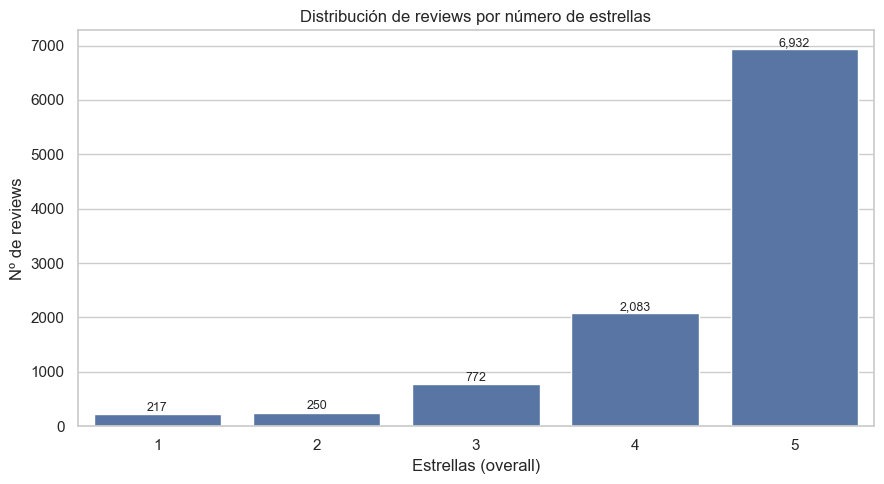

overall
1.0     217
2.0     250
3.0     772
4.0    2083
5.0    6932
Name: count, dtype: int64


In [ ]:
conteo_estrellas = df['overall'].value_counts().sort_index()

ax = sns.barplot(x=conteo_estrellas.index.astype(int), y=conteo_estrellas.values,
                 color='#4C72B0')
ax.set_title('Distribución de reviews por número de estrellas')
ax.set_xlabel('Estrellas (overall)')
ax.set_ylabel('Nº de reviews')
for i, v in enumerate(conteo_estrellas.values):
    ax.text(i, v + 60, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

print(conteo_estrellas)

**Observación:** la distribución está **muy sesgada hacia las valoraciones altas**: las reviews de 4 y 5 estrellas dominan el corpus, mientras que las negativas son minoritarias.

### 3.2 Número de reviews positivas y negativas (balanceo de clases)

/var/folders/fc/cdvkm_gd4w5472h7gr4mhpzr0000gn/T/ipykernel_17545/2782699229.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=conteo_sent.index, y=conteo_sent.values,


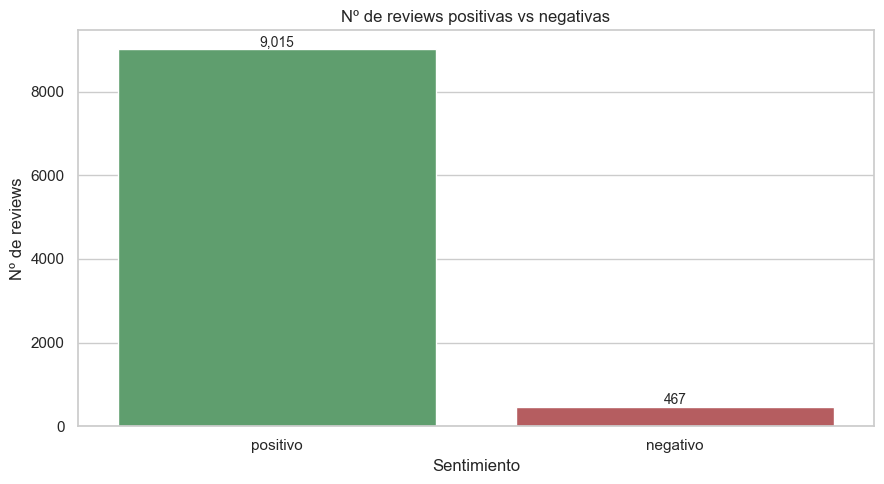

sentimiento
positivo    9015
negativo     467
Name: count, dtype: int64

Proporción positivo:negativo ≈ 19.3 : 1
Porcentaje de clase positiva: 95.1%


In [ ]:
conteo_sent = df_bin['sentimiento'].value_counts()
ratio = conteo_sent['positivo'] / conteo_sent['negativo']

ax = sns.barplot(x=conteo_sent.index, y=conteo_sent.values,
                 palette={'positivo': '#55A868', 'negativo': '#C44E52'})
ax.set_title('Nº de reviews positivas vs negativas')
ax.set_xlabel('Sentimiento'); ax.set_ylabel('Nº de reviews')
for i, v in enumerate(conteo_sent.values):
    ax.text(i, v + 60, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout(); plt.show()

print(conteo_sent)
print(f'\nProporción positivo:negativo ≈ {ratio:.1f} : 1')
print(f'Porcentaje de clase positiva: {conteo_sent["positivo"]/len(df_bin)*100:.1f}%')

Existe un **fuerte desbalanceo** (~19 reviews positivas por cada negativa). Un modelo que prediga *siempre "positivo"* alcanzaría ya ~95% de *accuracy*, por lo que el **accuracy no será una métrica fiable**


### 3.3 Longitud de las reviews

Métrica adicional: ¿cómo de largas son las reseñas? Nos ayuda a dimensionar el preprocesado y los
vectorizadores.

count    10254.0
mean        90.2
std        111.2
min          1.0
25%         31.0
50%         54.0
75%        104.0
max       2043.0
Name: n_palabras, dtype: float64


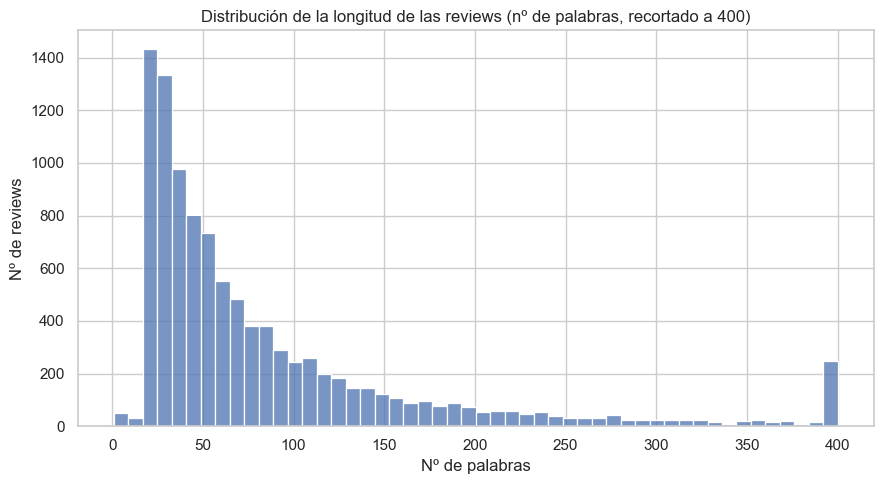

In [ ]:
df['n_palabras'] = df['reviewText'].str.split().apply(len)

print(df['n_palabras'].describe().round(1))

ax = sns.histplot(df['n_palabras'].clip(upper=400), bins=50, color='#4C72B0')
ax.set_title('Distribución de la longitud de las reviews (nº de palabras, recortado a 400)')
ax.set_xlabel('Nº de palabras'); ax.set_ylabel('Nº de reviews')
plt.tight_layout(); plt.show()

### 3.4 Cardinalidad del vocabulario


In [ ]:
EN_STOP = set(stopwords.words('english'))
patron_token = re.compile(r"[a-z']{2,}")  # palabras de >=2 letras

def tokenizar_simple(texto, quitar_stopwords=True):
    """Tokenización ligera solo para el EDA (no es el preprocesado final)."""
    tokens = patron_token.findall(texto.lower())
    tokens = [t.strip("'") for t in tokens if len(t.strip("'")) >= 2]
    if quitar_stopwords:
        tokens = [t for t in tokens if t not in EN_STOP]
    return tokens

# Tokenizamos todo el corpus (lo reutilizaremos en n-grams, wordclouds y Word2Vec)
df['tokens'] = df['reviewText'].apply(tokenizar_simple)

tokens_totales = [t for fila in df['tokens'] for t in fila]
vocabulario = set(tokens_totales)

print(f'Nº total de tokens (sin stopwords): {len(tokens_totales):,}')
print(f'Cardinalidad del vocabulario (tokens únicos): {len(vocabulario):,}')
print(f'Riqueza léxica (type-token ratio): {len(vocabulario)/len(tokens_totales):.4f}')

# Comparativa incluyendo stopwords, para dimensionar su peso
tokens_con_stop = [t for texto in df['reviewText'] for t in tokenizar_simple(texto, quitar_stopwords=False)]
print(f'\nNº total de tokens (con stopwords): {len(tokens_con_stop):,}')
print(f'Vocabulario (con stopwords): {len(set(tokens_con_stop)):,}')

Nº total de tokens (sin stopwords): 458,132
Cardinalidad del vocabulario (tokens únicos): 19,371
Riqueza léxica (type-token ratio): 0.0423

Nº total de tokens (con stopwords): 870,722
Vocabulario (con stopwords): 19,544


El vocabulario es de **varios miles de términos únicos** sobre cientos de
miles de tokens, con una **riqueza léxica baja** porque pocas palabras se repiten mucho. Las stopwords suponen una gran parte de los tokens pero no añaden vocabulario nuevo, lo que **justifica
eliminarlas** en el preprocesado.

### 3.5 N-grams más frecuentes

Analizamos las secuencias de palabras más repetidas (uni, bi y trigramas). Los n-grams revelan
expresiones típicas del dominio (instrumentos musicales) y términos con carga de sentimiento.

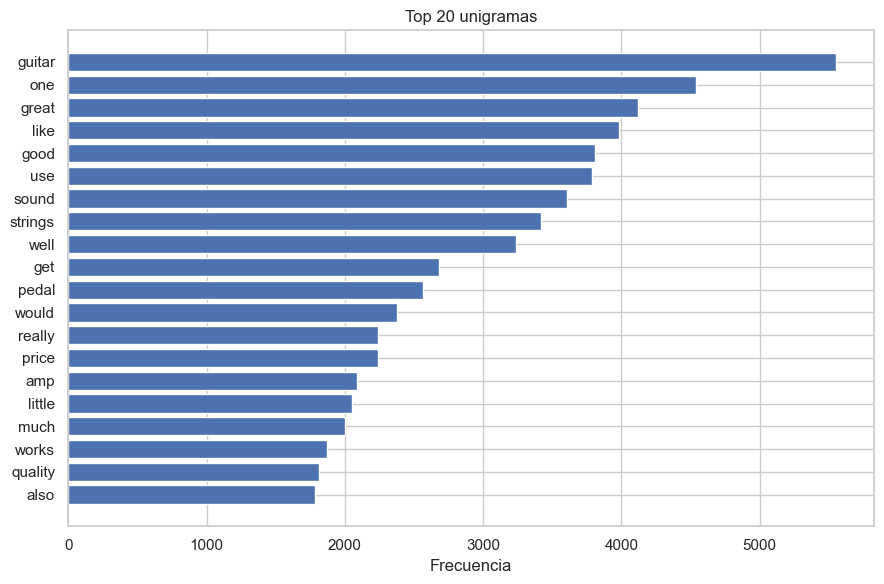

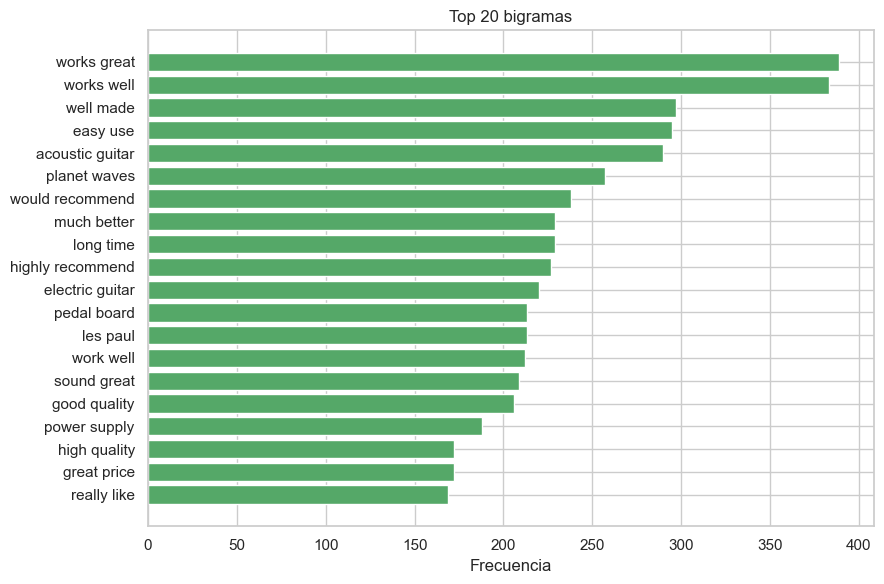

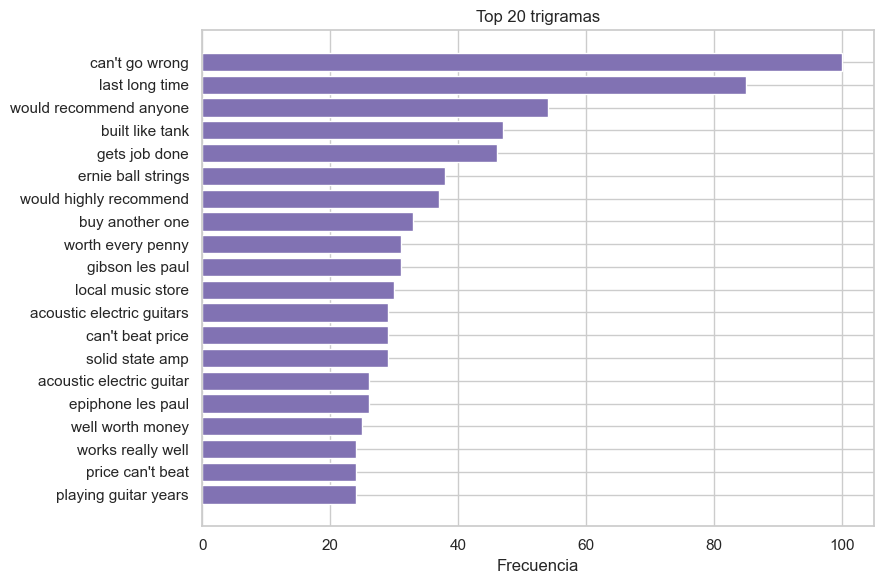

In [ ]:
def top_ngrams(lista_tokens_docs, n=1, top=20):
    contador = Counter()
    for tokens in lista_tokens_docs:
        contador.update(ngrams(tokens, n))
    return contador.most_common(top)

def plot_ngrams(top_list, titulo, color):
    etiquetas = [' '.join(g) for g, _ in top_list][::-1]
    valores = [c for _, c in top_list][::-1]
    plt.figure(figsize=(9, 6))
    plt.barh(etiquetas, valores, color=color)
    plt.title(titulo); plt.xlabel('Frecuencia')
    plt.tight_layout(); plt.show()

plot_ngrams(top_ngrams(df['tokens'], n=1, top=20), 'Top 20 unigramas', '#4C72B0')
plot_ngrams(top_ngrams(df['tokens'], n=2, top=20), 'Top 20 bigramas', '#55A868')
plot_ngrams(top_ngrams(df['tokens'], n=3, top=20), 'Top 20 trigramas', '#8172B3')


Los unigramas más frecuentes son términos del dominio (`guitar`, `string`,`sound`, `pedal`, `price`...) junto a palabras valorativas(`great`, `good`, `well`). Los bi/trigramas capturan expresiones con sentimiento explícito (`works great`, `highly recommend`, `well made`) y construcciones que un modelo de unigramas perdería

Comparamos además los unigramas más frecuentes **por clase** para ver qué palabras
diferencian reviews positivas de negativas.

In [ ]:
tok_pos = df[df['sentimiento'] == 'positivo']['tokens']
tok_neg = df[df['sentimiento'] == 'negativo']['tokens']

print('Top 15 en reviews POSITIVAS:')
print([' '.join(g) for g, _ in top_ngrams(tok_pos, 1, 15)])
print('\nTop 15 en reviews NEGATIVAS:')
print([' '.join(g) for g, _ in top_ngrams(tok_neg, 1, 15)])

Top 15 en reviews POSITIVAS:
['guitar', 'one', 'great', 'like', 'good', 'use', 'sound', 'strings', 'well', 'pedal', 'get', 'price', 'really', 'would', 'amp']

Top 15 en reviews NEGATIVAS:
['one', 'guitar', 'like', 'get', 'would', 'sound', 'use', 'good', 'pedal', 'strings', 'work', 'really', 'better', 'back', 'amp']


Muchas palabras frecuentes son comunes a ambas clases, pero en las negativas aparecen términos como `would`, `back`, `return`, `problem`,
`don't`...

### 3.6 Nubes de palabras

Visualizamos las palabras más frecuentes de cada clase con *word clouds* (el tamaño es proporcional
a la frecuencia).

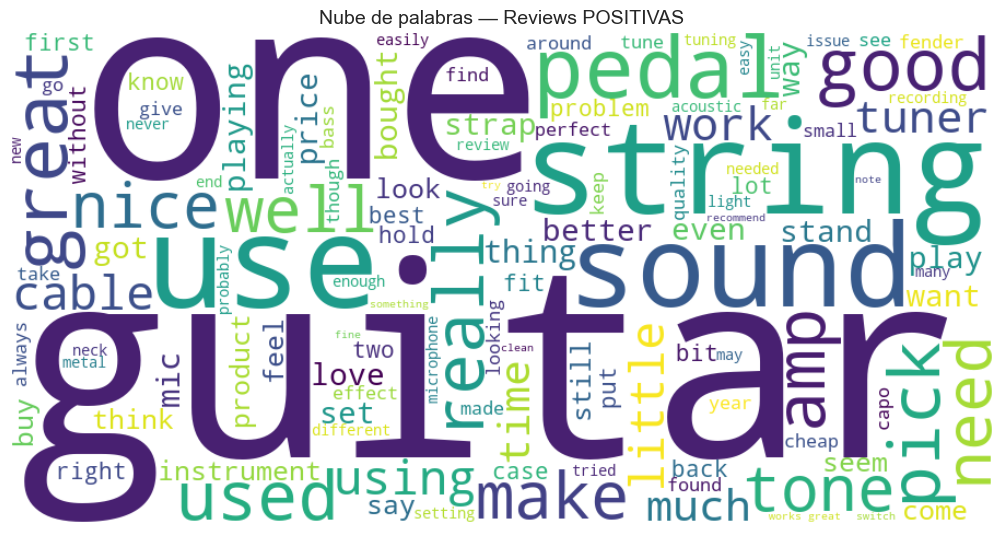

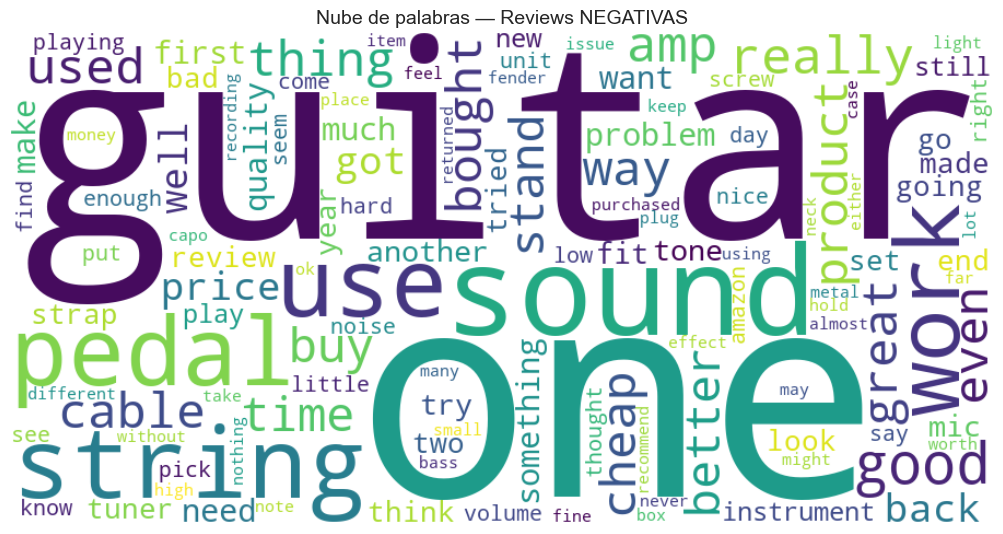

In [ ]:
def nube(tokens_docs, titulo):
    texto = ' '.join(t for tokens in tokens_docs for t in tokens)
    wc = WordCloud(width=900, height=450, background_color='white',
                   colormap='viridis', max_words=120,
                   random_state=RANDOM_STATE).generate(texto)
    plt.figure(figsize=(11, 5.5))
    plt.imshow(wc, interpolation='bilinear'); plt.axis('off')
    plt.title(titulo, fontsize=14)
    plt.tight_layout(); plt.show()

nube(tok_pos, 'Nube de palabras — Reviews POSITIVAS')
nube(tok_neg, 'Nube de palabras — Reviews NEGATIVAS')

Ambas nubes comparten el vocabulario (`guitar`, `string`,
`sound`...), lo que indica que **el tema no separa las clases** yla diferencia está en los matices
valorativos. Visualmente se aprecia más presencia de términos positivos (`great`, `good`, `love`) en la primera y de quejas en la segunda.

### 3.7 Word embeddings con Word2Vec (visualización en 2D)

Entrenamos un modelo **Word2Vec** sobre el corpus tokenizado para aprender representaciones
vectoriales de las palabras a partir de su contexto. Después elegimos varias palabras del dominio,
obtenemos sus **10 vecinos más similares** y los proyectamos a **2 dimensiones con PCA** para ver
si el modelo ha capturado relaciones semánticas coherentes.

In [ ]:
# Entrenamos Word2Vec sobre las listas de tokens (skip-gram)
w2v = Word2Vec(
    sentences=df['tokens'].tolist(),
    vector_size=100,   # dimensión de los embeddings
    window=5,          # ventana de contexto
    min_count=5,       # ignora palabras muy raras
    sg=1,              # 1 = skip-gram (bueno para corpus pequeños)
    workers=4,
    epochs=20,
    seed=RANDOM_STATE,
)
print(f'Vocabulario del modelo Word2Vec: {len(w2v.wv):,} palabras')

Vocabulario del modelo Word2Vec: 6,218 palabras


In [ ]:
# Comprobamos algunas similitudes y analogías
for w in ['guitar', 'sound', 'price', 'string', 'quality']:
    if w in w2v.wv:
        similares = ', '.join(f'{p}' for p, _ in w2v.wv.most_similar(w, topn=5))
        print(f'{w:>8} → {similares}')

  guitar → guitars, electric, acoustic, dreadnaught, instrument
   sound → tone, sounds, fullness, sounding, warmth
   price → paid, coast, prices, whats, bread
  string → strings, sting, peg, windings, winders
 quality → craftsmanship, workmanship, price, value, compares


/var/folders/fc/cdvkm_gd4w5472h7gr4mhpzr0000gn/T/ipykernel_17545/1261262712.py:33: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  plt.tight_layout(); plt.show()
/Users/isma/.pyenv/versions/3.8.18/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


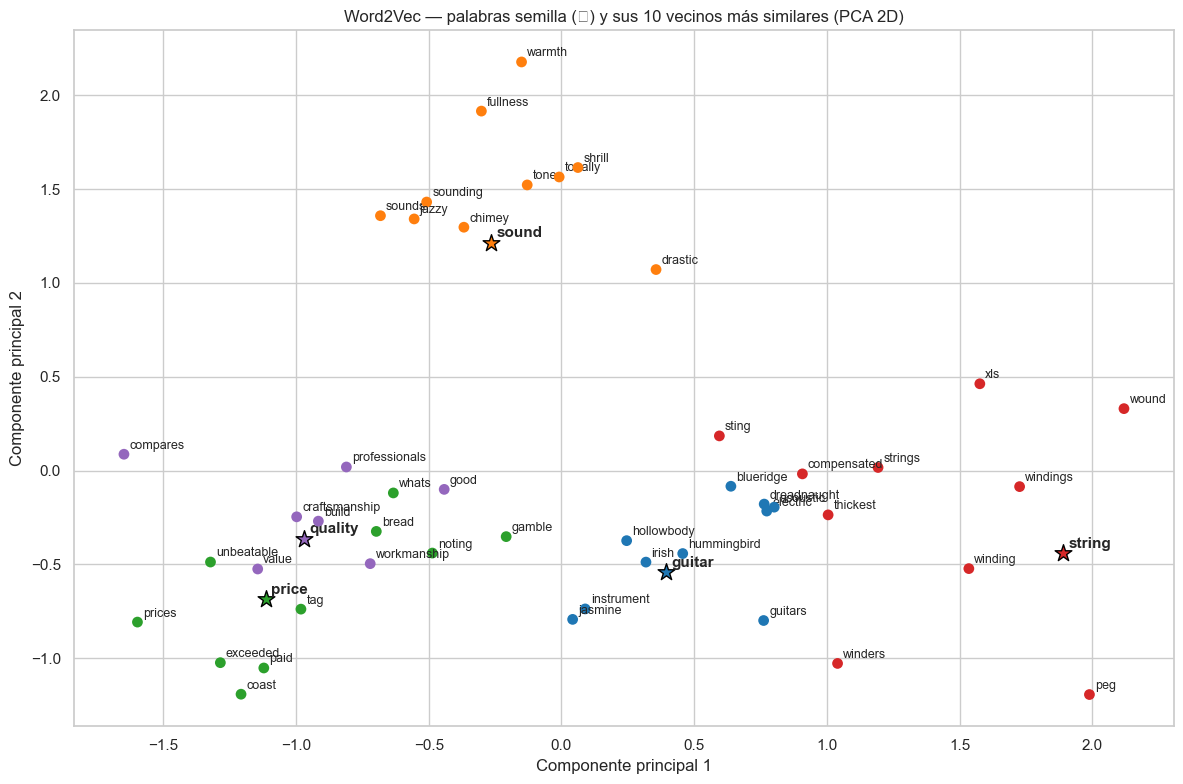

In [ ]:
# Palabras semilla a visualizar (4-5) y sus 10 más similares
palabras_semilla = [w for w in ['guitar', 'sound', 'price', 'string', 'quality'] if w in w2v.wv]

palabras, grupos = [], []
for semilla in palabras_semilla:
    palabras.append(semilla); grupos.append(semilla)
    for vecino, _ in w2v.wv.most_similar(semilla, topn=10):
        if vecino not in palabras:
            palabras.append(vecino); grupos.append(semilla)

# Proyección a 2D con PCA
vectores = np.array([w2v.wv[p] for p in palabras])
coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(vectores)

plt.figure(figsize=(12, 8))
colores = sns.color_palette('tab10', len(palabras_semilla))
mapa_color = {s: colores[i] for i, s in enumerate(palabras_semilla)}

for i, palabra in enumerate(palabras):
    es_semilla = palabra in palabras_semilla
    plt.scatter(coords[i, 0], coords[i, 1],
                color=mapa_color[grupos[i]],
                s=160 if es_semilla else 60,
                marker='*' if es_semilla else 'o',
                edgecolors='black' if es_semilla else 'none', zorder=3)
    plt.annotate(palabra, (coords[i, 0], coords[i, 1]),
                 fontsize=11 if es_semilla else 9,
                 fontweight='bold' if es_semilla else 'normal',
                 xytext=(4, 4), textcoords='offset points')

plt.title('Word2Vec — palabras semilla (★) y sus 10 vecinos más similares (PCA 2D)')
plt.xlabel('Componente principal 1'); plt.ylabel('Componente principal 2')
plt.tight_layout(); plt.show()

Word2Vec captura agrupaciones aunque el conjunto de datos es pequeño.
Ademñas ,las palabras se organizan en vecindarios temáticos (términos sobre tipos de instrumentos, sobre sonido/calidad, sobre precio...) y cada palabra semilla aparece rodeada de términos relacionados

## 4. Conclusiones de la exploración

**Sobre el corpus**
- Trabajamos con **~10.000 reviews** en inglés de la categoría *Musical Instruments* de Amazon, sin valores nulos en el texto y con reseñas de longitud corta-media.
- El **vocabulario** es de varios miles de términos únicos con **baja riqueza léxica**: unas pocas palabras concentran gran parte de las apariciones, y las stopwords pesan mucho en volumen pero poco en vocabulario así que **conviene eliminarlas** en el preprocesado.

**Sobre el problema de sentimiento**
- La etiqueta se deriva de las estrellas (**4-5 para positivo, 1-2 para negativo, 3 estrellas descartada**).
- Existe un **fuerte desbalanceo de clases (~19:1 a favor de positivo)**:
  - El **accuracy no es fiable**
  - Habrá que **tratar el desbalanceo**

**Sobre el contenido textual**
- Los **n-grams** muestran vocabulario de dominio (`guitar`, `string`, `sound`, `pedal`) junto a términos valorativos y los **bigramas/trigramas** capturan expresiones de sentimiento
  (`works great`, `highly recommend`)
- **Word2Vec** captura relaciones semánticas coherentes, lo que valida la calidad del corpus.
